In [2]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable

   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]



In [5]:
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('SMOTE imported successfully.')

#loading the dataset
data = pd.read_csv('creditcard.csv')
print('Dataset loaded successfully.')

print(f'Dataset shape: {data.shape}')

SMOTE imported successfully.
Dataset loaded successfully.
Dataset shape: (284807, 31)


In [8]:
#apply smote to the dataset 
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]
print(f'Number of fraudulent transactions: {len(fraud)}')
print(f'Number of valid transactions: {len(valid)}')

#applying smote to the dataset
X = data.drop('Class', axis=1)
y = data['Class']

smote = SMOTE(sampling_strategy='minority', random_state=42)

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   

#smotting the training data
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)
print('SMOTE applied successfully.')

#printing the shape of the smoted data
print(f'Shape of x_train_smote: {x_train_smote.shape}')
print(f'Shape of y_train_smote: {y_train_smote.shape}')

#printing the value counts of the smoted data
print('Value counts of y_train_smote:')
print(y_train_smote.value_counts())

print()


Number of fraudulent transactions: 492
Number of valid transactions: 284315
SMOTE applied successfully.
Shape of x_train_smote: (454902, 30)
Shape of y_train_smote: (454902,)
Value counts of y_train_smote:
Class
0    227451
1    227451
Name: count, dtype: int64



In [9]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(x_train_smote, y_train_smote)
print('Random Forest Classifier trained successfully.')

Random Forest Classifier trained successfully.


In [10]:

#predicting the values
y_pred = random_forest.predict(x_test)
print('Predictions made successfully.')

Predictions made successfully.


Accuracy: 99.9526 %
Precision: 87.3684 %
F1 Score: 86.0104 %
Recall score: 84.6939 %
Matthews Correlation Coefficient: 0.8600
Confusion Matrix:
[[56852    12]
 [   15    83]]


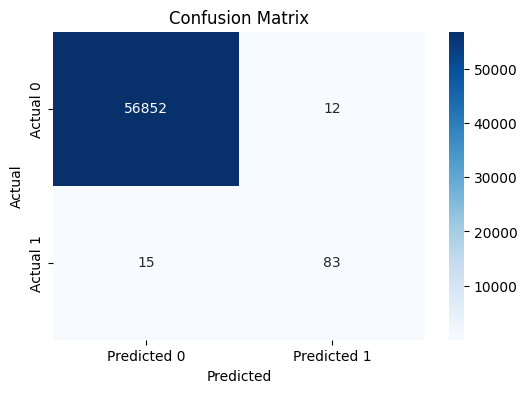

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import matthews_corrcoef   

#accuracy
acc_2 = accuracy_score(y_test, y_pred)
print('Accuracy: {:.4f} %'.format(acc_2 * 100))

#precision score    
precision_score_of_model_v2 = precision_score(y_test, y_pred)
print('Precision: {:.4f} %'.format(precision_score_of_model_v2 * 100))

#f1 score
f1_score_of_model = f1_score(y_test, y_pred)
print('F1 Score: {:.4f} %'.format(f1_score_of_model * 100))

#recall score   
recall_score_oof_model = recall_score(y_test, y_pred)
print('Recall score: {:.4f} %'.format(recall_score_oof_model * 100))

#mathews correlation coefficient
mathew_perry = matthews_corrcoef(y_test, y_pred)
print('Matthews Correlation Coefficient: {:.4f}'.format(mathew_perry))



import matplotlib.pyplot as plt
import seaborn as sns

#confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1']
            )
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [13]:
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
x_train_adasyn, y_train_adasyn = adasyn.fit_resample(x_train, y_train)
print('ADASYN applied successfully.')
print('Value counts of y_train_adasyn:')
print(y_train_adasyn.value_counts())

ADASYN applied successfully.
Value counts of y_train_adasyn:
Class
0    227451
1    227373
Name: count, dtype: int64


In [14]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)

#fitting model
model.fit(x_train_adasyn, y_train_adasyn)
print('Random Forest Classifier trained successfully on ADASYN data.')

Random Forest Classifier trained successfully on ADASYN data.


Predictions made successfully on ADASYN data.
Accuracy: 99.9473 %
Precision: 85.4167 %
F1 Score: 84.5361 %
Recall score: 83.6735 %
Matthews Correlation Coefficient: 0.8451
Confusion Matrix:


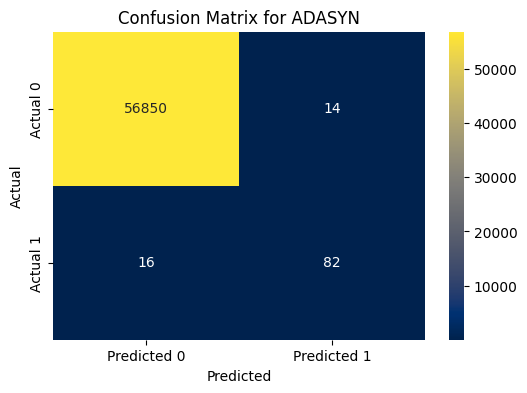

In [16]:
#predicting the values
y_pred_adasyn = model.predict(x_test)
print('Predictions made successfully on ADASYN data.')

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import matthews_corrcoef

#accuracy
acc_adasyn = accuracy_score(y_test, y_pred_adasyn)
print('Accuracy: {:.4f} %'.format(acc_adasyn * 100))

#precision score
precision_score_of_model_adasyn = precision_score(y_test, y_pred_adasyn)
print('Precision: {:.4f} %'.format(precision_score_of_model_adasyn * 100))

#f1 score
f1_score_of_model_adasyn = f1_score(y_test, y_pred_adasyn)
print('F1 Score: {:.4f} %'.format(f1_score_of_model_adasyn * 100))

#recall score
recall_score_of_model_adasyn = recall_score(y_test, y_pred_adasyn)
print('Recall score: {:.4f} %'.format(recall_score_of_model_adasyn * 100))

#mathews correlation coefficient
mathew_perry_adasyn = matthews_corrcoef(y_test, y_pred_adasyn)
print('Matthews Correlation Coefficient: {:.4f}'.format(mathew_perry_adasyn))

#confusion matrix
conf_matrix_adasyn = confusion_matrix(y_test, y_pred_adasyn)
print('Confusion Matrix:')

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_adasyn, 
            annot=True,
            fmt='d',
            cmap='cividis',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for ADASYN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()  